## setup


In [ ]:
## import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report


In [2]:
#configurations
# display all columns
pd.set_option("display.max_columns",None)
sns.set_theme(style="darkgrid")


RANDOM_STATE = 42

## Problem statement

## Data collection

In [3]:
## load csv file
df = pd.read_csv("sonar_data.csv",header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:
df.shape

(208, 61)

## Data analysis and visualization(EDA)

In [4]:
## basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null    float64
 22  22

In [6]:
## missing values
df.isnull().sum()

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64

In [8]:
## identify encoded missing values
for col in df.columns:
    print([df[col].value_counts()])

[0
0.0201    5
0.0094    3
0.0131    3
0.0100    3
0.0209    3
         ..
0.0272    1
0.0187    1
0.0323    1
0.0522    1
0.0303    1
Name: count, Length: 177, dtype: int64]
[1
0.0523    2
0.0582    2
0.0453    2
0.0086    2
0.0309    2
         ..
0.0387    1
0.0258    1
0.0346    1
0.0101    1
0.0353    1
Name: count, Length: 182, dtype: int64]
[2
0.0277    2
0.0623    2
0.0347    2
0.0842    2
0.0136    2
         ..
0.0329    1
0.0488    1
0.0168    1
0.0180    1
0.0490    1
Name: count, Length: 190, dtype: int64]
[3
0.0108    3
0.0608    3
0.0250    2
0.0489    2
0.0394    2
         ..
0.0570    1
0.0848    1
0.0177    1
0.0564    1
0.0292    1
Name: count, Length: 181, dtype: int64]
[4
0.1158    2
0.0305    2
0.0647    2
0.0597    2
0.1615    2
         ..
0.0393    1
0.0760    1
0.0351    1
0.0167    1
0.0214    1
Name: count, Length: 193, dtype: int64]
[5
0.0438    2
0.0526    2
0.0771    2
0.0284    2
0.0690    2
         ..
0.1630    1
0.0958    1
0.1171    1
0.1354    1
0.

In [9]:
## target distribution
print(df[60].value_counts())
print(df[60].value_counts(normalize=True))

60
M    111
R     97
Name: count, dtype: int64
60
M    0.533654
R    0.466346
Name: proportion, dtype: float64


In [11]:
print(df[60].value_counts())
print(df[60].value_counts(normalize=True))

60
1    111
0     97
Name: count, dtype: int64
60
1    0.533654
0    0.466346
Name: proportion, dtype: float64


In [12]:
## identify duplicate rows
df_duplicated = df.duplicated()
print(f"number of duplicated: {df.duplicated().sum()}")
print(f"duplicaated rows:\n {df_duplicated}")

number of duplicated: 0
duplicaated rows:
 0      False
1      False
2      False
3      False
4      False
       ...  
203    False
204    False
205    False
206    False
207    False
Length: 208, dtype: bool


In [13]:
## remove duplicated
df  = df.drop_duplicates()
print(f"shape after remove duplicate rows: {df.shape}")

## this dataset doesn't contain any null values and duplicate rows

shape after remove duplicate rows: (208, 61)


In [14]:
## return number of unique values
num_of_rows = len(df)
num_of_unique = df.nunique()

constant_columns = num_of_unique[num_of_unique==1].index.to_list()
print(constant_columns)
# number

[]


In [15]:
## quasi constant - more that 95% values are containing one value
quasi_constant_cols = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True,dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_columns:
        quasi_constant_cols.append(col)


print(f"quasi constant columns(more thean 95% of values containing one value):\n {quasi_constant_cols}")

quasi constant columns(more thean 95% of values containing one value):
 []


In [16]:
## group the data base on taarget column to see mean of each features on target's catogeries
## if values(mean) are same for each catogory, we can assume model will not able to find difference between target categories
df.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,0.174713,0.191589,0.226249,0.268963,0.307636,0.375611,0.417100,0.448240,0.466762,0.500229,0.542270,0.569290,0.612959,0.653761,0.668809,0.692762,0.687737,0.673145,0.632680,0.579934,0.529762,0.451619,0.440841,0.44568,0.455530,0.460710,0.417330,0.348868,0.313709,0.318057,0.285428,0.252338,0.211822,0.175132,0.142312,0.116949,0.094458,0.069488,0.038449,0.017796,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024
1,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,0.289581,0.301459,0.314426,0.320692,0.331182,0.380999,0.415007,0.455882,0.538062,0.617941,0.667426,0.672325,0.676701,0.689165,0.681204,0.706075,0.714754,0.712269,0.650283,0.581796,0.482378,0.428049,0.396577,0.36614,0.337553,0.318553,0.317034,0.331608,0.336365,0.305221,0.292594,0.300975,0.276883,0.248106,0.245225,0.198804,0.146917,0.110594,0.063708,0.022721,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930


In [17]:
df.groupby(60).std()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.014687,0.024011,0.029101,0.031172,0.047217,0.065025,0.065155,0.079772,0.099887,0.113151,0.113363,0.134671,0.138082,0.166283,0.219055,0.255401,0.289979,0.269781,0.258432,0.259433,0.248753,0.260639,0.243941,0.233179,0.250009,0.238802,0.220013,0.205935,0.234491,0.233361,0.201619,0.213180,0.217085,0.251312,0.261250,0.262311,0.242986,0.223805,0.216223,0.196823,0.177206,0.165874,0.130301,0.107422,0.095663,0.093840,0.067765,0.048244,0.030441,0.012557,0.008632,0.007109,0.006174,0.005389,0.005137,0.004773,0.005702,0.004841,0.005114,0.003669
1,0.027074,0.037840,0.044014,0.054497,0.059790,0.052620,0.058179,0.087190,0.122237,0.137366,0.125359,0.124149,0.130742,0.159738,0.193066,0.211929,0.239680,0.255275,0.254108,0.254087,0.252410,0.242758,0.252850,0.244037,0.241384,0.236752,0.266410,0.261030,0.245937,0.210175,0.222801,0.213642,0.195461,0.206225,0.245456,0.248427,0.228149,0.203718,0.183123,0.161806,0.166338,0.168666,0.139806,0.144418,0.174053,0.151395,0.094474,0.067118,0.036382,0.014226,0.013528,0.010770,0.007658,0.008463,0.008404,0.006403,0.005884,0.007460,0.006917,0.005958


In [18]:
## descriptive stats
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,0.236013,0.250221,0.273305,0.296568,0.320201,0.378487,0.415983,0.452318,0.504812,0.563047,0.609060,0.624275,0.646975,0.672654,0.675424,0.699866,0.702155,0.694024,0.642074,0.580928,0.504475,0.439040,0.417220,0.403233,0.392571,0.384848,0.363807,0.339657,0.325800,0.311207,0.289252,0.278293,0.246542,0.214075,0.197232,0.160631,0.122453,0.091424,0.051929,0.020424,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507,0.533654
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,0.132705,0.140072,0.140962,0.164474,0.205427,0.232650,0.263677,0.261529,0.257988,0.262653,0.257818,0.255883,0.250175,0.239116,0.244926,0.237228,0.245657,0.237189,0.240250,0.220749,0.213992,0.213237,0.206513,0.231242,0.259132,0.264121,0.239912,0.212973,0.199075,0.178662,0.171111,0.168728,0.138993,0.133291,0.151628,0.133938,0.086953,0.062417,0.035954,0.013665,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031,0.500070
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,0.028900,0.023600,0.018400,0.027300,0.003100,0.016200,0.034900,0.037500,0.049400,0.065600,0.051200,0.021900,0.056300,0.023900,0.024000,0.092100,0.048100,0.028400,0.014400,0.061300,0.048200,0.040400,0.047700,0.021200,0.022300,0.008000,0.035100,0.038300,0.037100,0.011700,0.036000,0.005600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600,0.000000
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,0.129250,0.133475,0.166125,0.175175,0.164625,0.196300,0.205850,0.242075,0.299075,0.350625,0.399725,0.406925,0.450225,0.540725,0.525800,0.544175,0.531900,0.534775,0.463700,0.411400,0.345550,0.281400,0.257875,0.217575,0.179375,0.154350,0.160100,0.174275,0.173975,0.186450,0.163100,0.158900,0.155200,0.126875,0.094475,0.068550,0.064250,0.045125,0.026350,0.011550,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100,0.000000
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,0.224800,0.249050,0.263950,0.281100,0.281700,0.304700,0.308400,0.368300,0.434950,0.542500,0.617700,0.664900,0.699700,0.698500,0.721100,0.754500,0.745600,0.731900,0.680800,0.607150,0.490350,0.429600,0.391200,0.351050,0.312750,0.321150,0.306300,0.312700,0.283500,0.278050,0.259500,0.245100,0.222550,0.177700,0.148000,0.121350,0.101650,0.078100,0.044700,0.017900,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300,1.000000
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,0.301650,0.331250,0.351250,0.386175,0.452925,0.535725,0.659425,0.679050,0.731400,0.809325,0.816975,0.831975,0.848575,0.872175,0.873725,0.893800,0.917100,0.900275,0.852125,0.735175,0.641950,0.580300,0.556125,0.596125,0.593350,0.556525,0.518900,0.440550,0.434900,0.424350,0.387525,0.384250,0

## visualizations

In [24]:
# ## distribution - histogram
# for col in df.columns:
#     plt.figure(figsize = (4,3))
#     sns.histplot(df[col],kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")

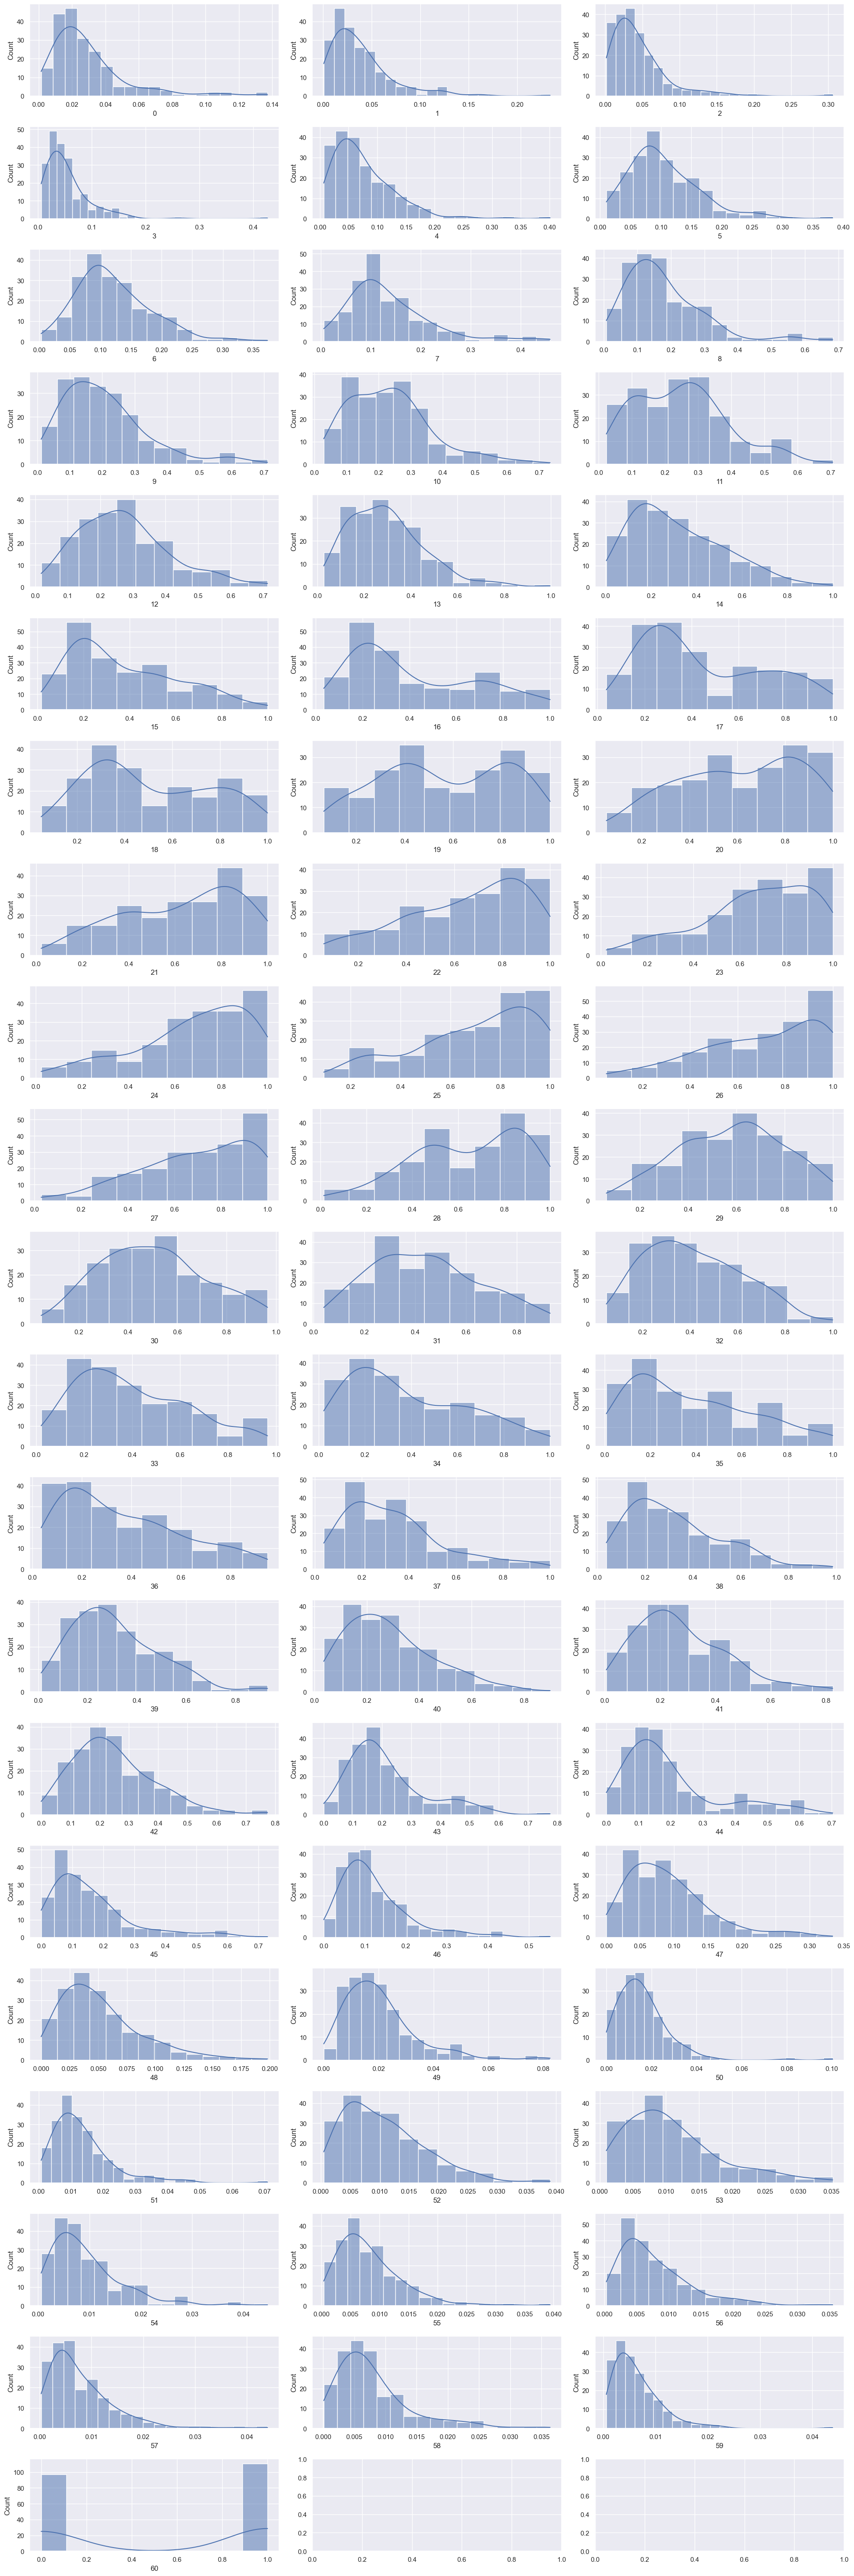

In [29]:
fig, axes = plt.subplots(21, 3, figsize=(20, 60))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])

plt.tight_layout()
plt.show()

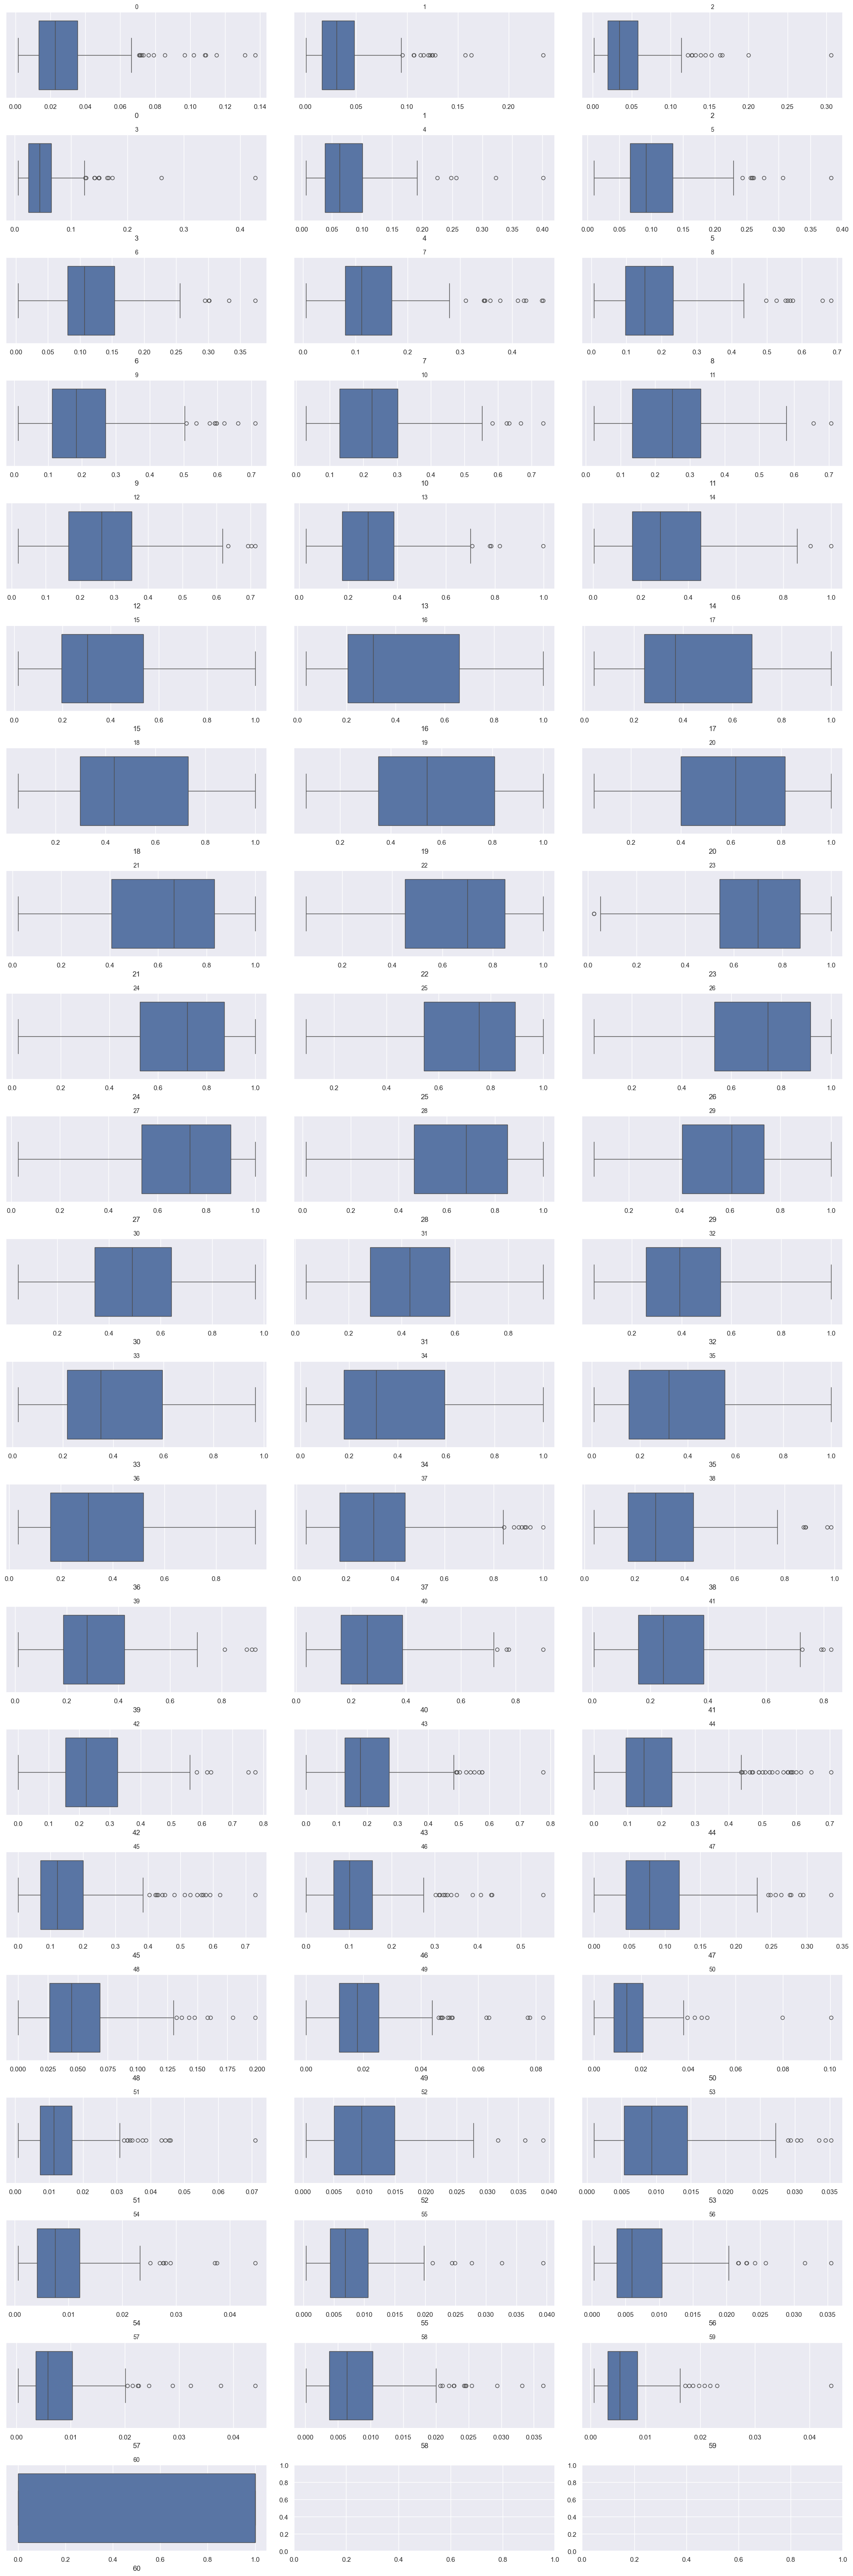

In [ ]:
### understand outliers
fig, axes = plt.subplots(21, 3, figsize=(20, 60))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot( x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

## because outliers are not much out of range we don't have to care much about them
## all outliers are not meant to be treated, some can be valuebal 

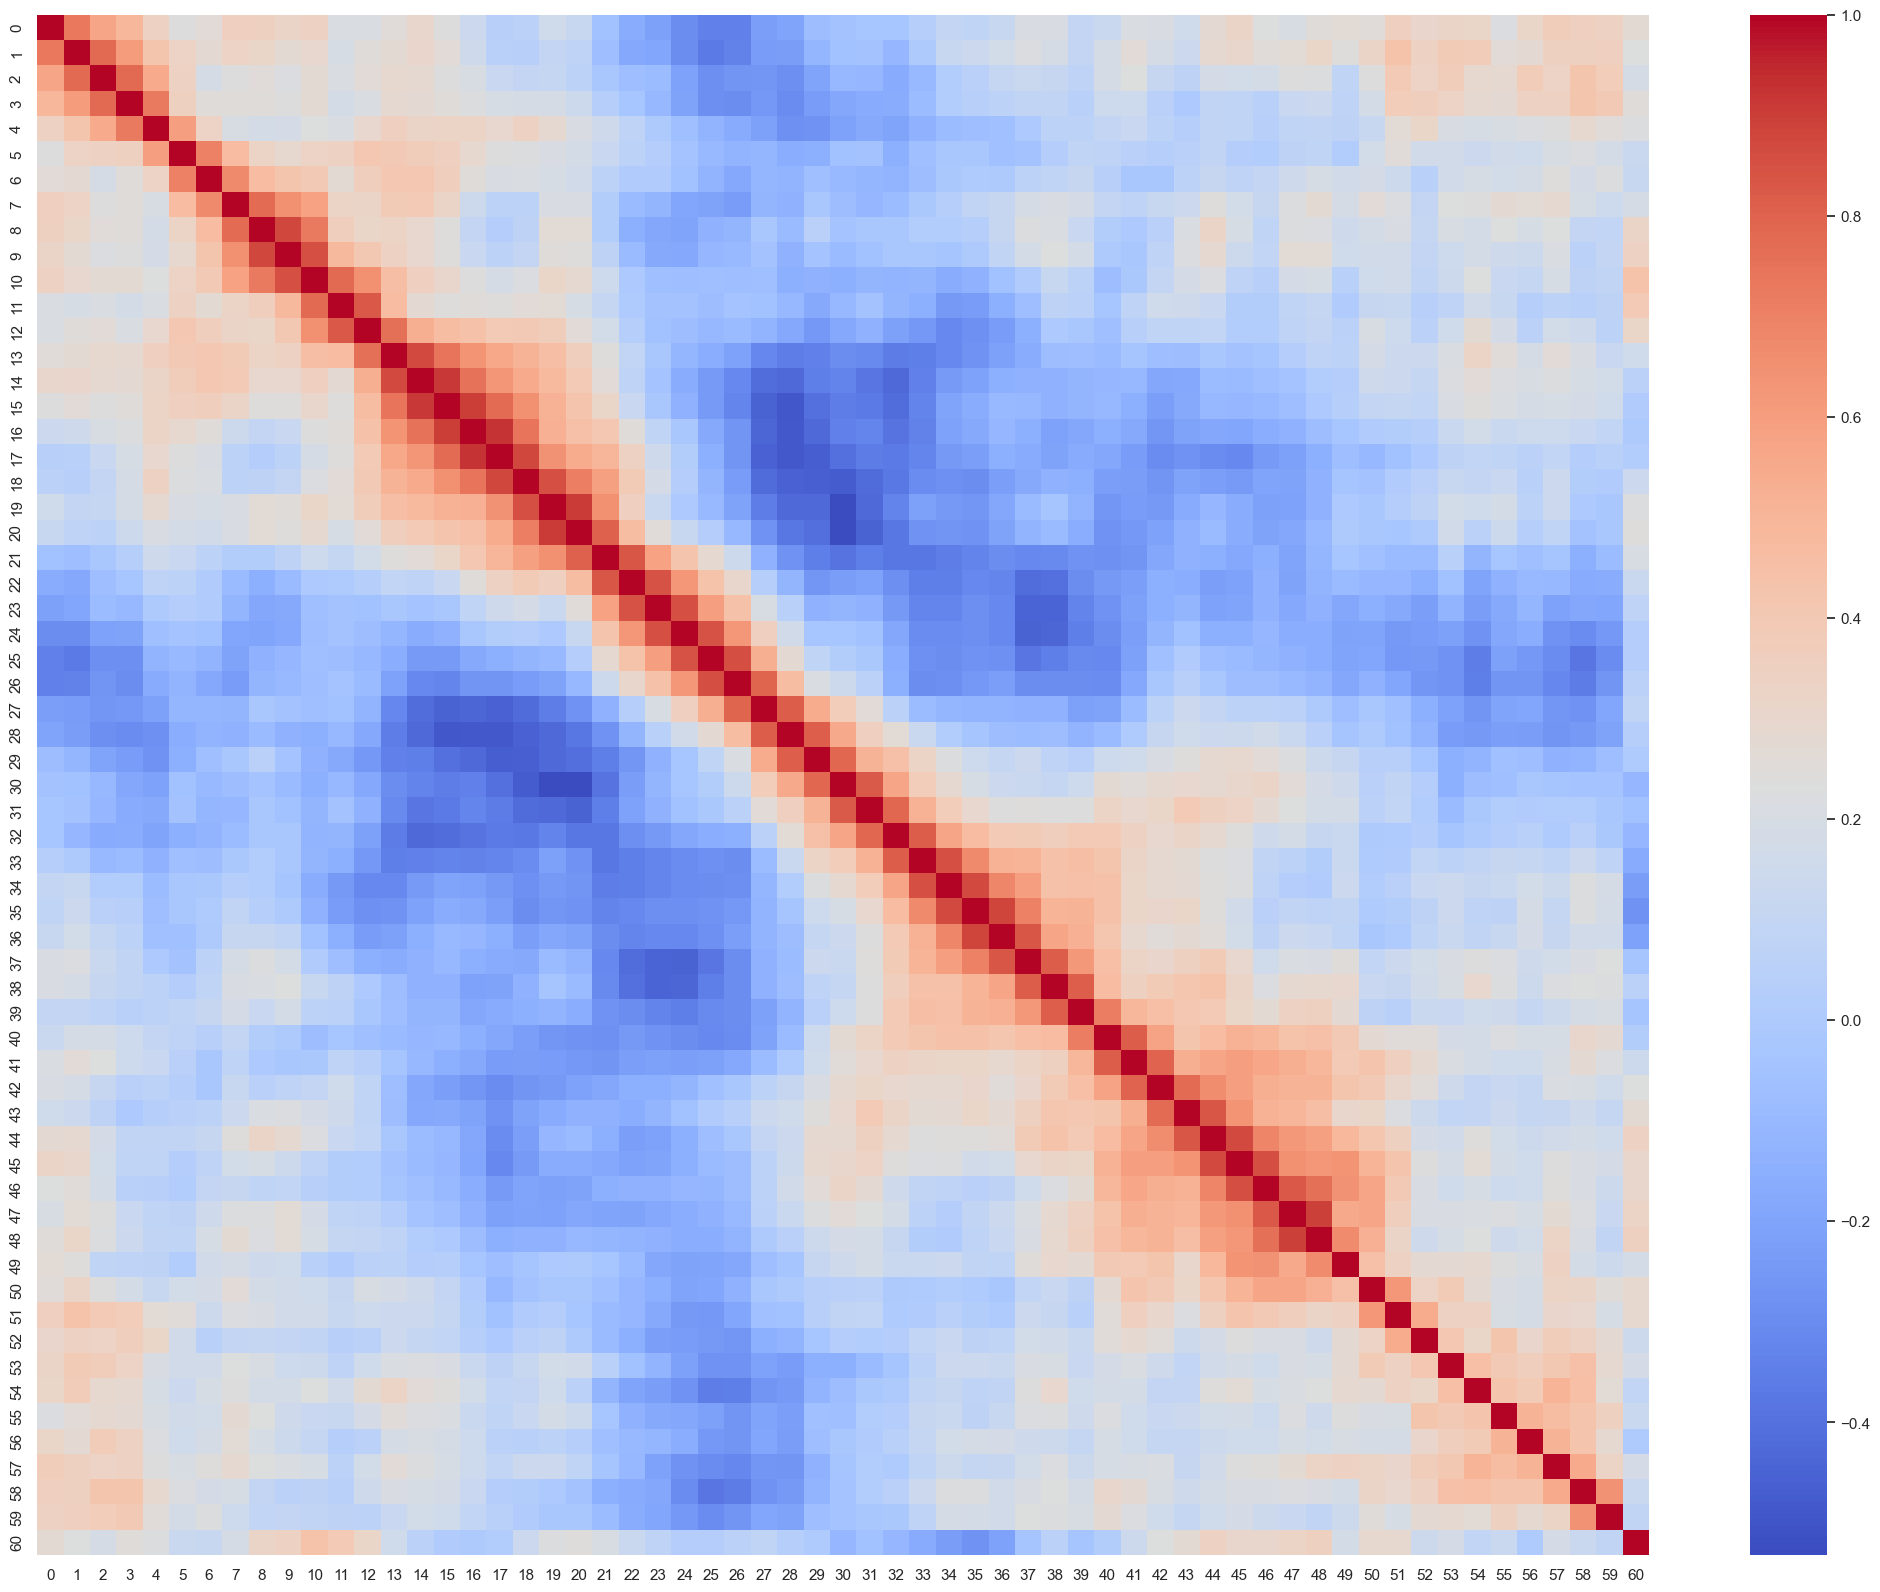

In [44]:
## corelation heatmap
plt.figure(figsize=(26, 20))

sns.heatmap(
    df.corr(),
      cmap="coolwarm"
#     annot=True,      # Show correlation values
#     fmt=".2f"        # Display 2 decimal places
 )

plt.show()

- We often drop highly correlated columns because they contain very similar information, which can cause problems for some machine learning models.
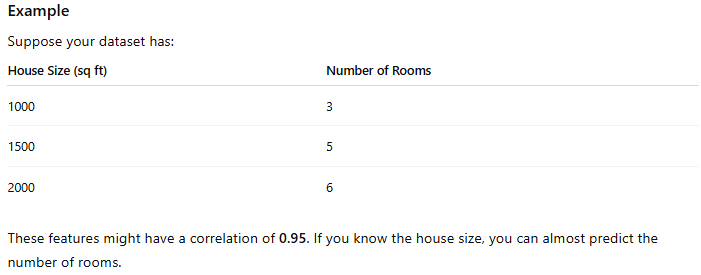

- Highly correlated features make it difficult for the model to determine which feature is actually responsible for the prediction.

### EDA insights
- dataset have fever rows so we can use simple, less complex model
- all features are numerical 
- no missing values
- No constant columns or quasi constant columns
- feature wise mean and satndard deviation regards to each catogory of target is not same or difference is not low(clear), so we can assume model will be able classify well.(GROUP BY)
- most columns are right skeved,outliers are not so much out of range so we don't have deal with them(at least for now)
- corelations between features are quite high, but not showing more that 0.95.

## Data pre-processing

In [18]:
## map labels
df[60]=df[60].map({"R":0,"M":1})
df[60]

0      0
1      0
2      0
3      0
4      0
      ..
203    1
204    1
205    1
206    1
207    1
Name: 60, Length: 208, dtype: int64

In [19]:
## separate feature and target
X = df.drop(columns=[60])
y = df[60]

In [20]:
## train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)

In [21]:
## feature scaling
scaler=StandardScaler()


In [22]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## model selection and training

In [23]:
from sklearn.svm import SVC
model = SVC()

In [24]:
## train model
model.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Evaluation

In [25]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train,y_train_pred)
print(f"Training data accuracy: {train_acc}")

Training data accuracy: 0.9698795180722891


In [29]:
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test,y_test_pred)
print(f"Testing data accuracy: {test_acc}")

Testing data accuracy: 0.9285714285714286


In [30]:
print("Classification report for training data:")
print(classification_report(y_train,y_train_pred))

Classification report for training data:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        77
           1       1.00      0.94      0.97        89

    accuracy                           0.97       166
   macro avg       0.97      0.97      0.97       166
weighted avg       0.97      0.97      0.97       166



In [31]:
print("Classification report for test data:")
print(classification_report(y_test,y_test_pred))

Classification report for test data:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



### building predictive system

In [32]:
def predict_object(input_features):
    #scale data
    scaled_data = scaler.transform(input_features)
    prediction = model.predict(scaled_data)
    if prediction == 1:
        return "Mine"
    else:
        return "Rock" 
    
     


In [73]:
y_test.head()

103    1
168    1
129    1
182    1
90     0
Name: 60, dtype: int64

In [ ]:
## get data
data_x = X_test.loc[90]

In [ ]:
## actual label
data_y = y_test.loc[90] 
data_y

np.int64(1)

In [76]:
# predict
result = predict_object([data_x])
print(result)

Rock
